# Description of the final project

## Introduction

This project consists of two parts. The first part is devoted to Computer Vision and based on the first four weeks of the course. The second part is on Natural Language Processing and based on weeks 5 and 6.


## Detailed Task Description

### Part 1: Computer vision
In this part you are going to work with [FOOD-101](https://data.vision.ee.ethz.ch/cvl/datasets_extra/food-101/), which contains images of various types of food - 101 classes in total.
The dataset contains the "images" folder with images for each food class, and a "meta" folder with annotations divided into train and test subsets. Annotations are provided in two formats JSON and TXT. You can use any of them. In both cases, the annotation file contains a list of image paths for each food class.

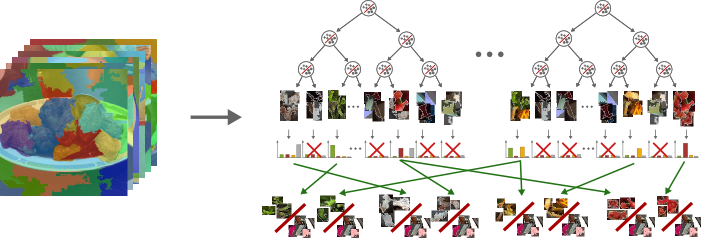

[Food-101 – Mining Discriminative Components with Random Forests](https://data.vision.ee.ethz.ch/cvl/datasets_extra/food-101/static/bossard_eccv14_food-101.pdf)

*Lukas Bossard, Matthieu Guillaumin, Luc Van Gool*

In this part of the task you should perform all the model training on train data and evaluate your models on test data.



Use **[accuracy](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.accuracy_score.html)** metric for scoring.



### [5%] 1. Data analysis


* 1.1  (3%) Download the [FOOD-101 dataset](https://data.vision.ee.ethz.ch/cvl/datasets_extra/food-101/), visualize several examples from different classes and calculate basic statistics (example number, class distribution, etc.).

**Note:** If you have limited computional resources, you can use only a subset of the original dataset which contains 10 or 50 classes. *There will be no punishement for this*. You can choose any classes you like from the original 101. If you decide to use fewer classes, please write this clearly in your solution and provide a reason for choosing this option.

* 1.2  (2%) Split the data from train into `current_train` and `current_val` (`val_size = 10%`). Do not forget to fix `random_state` for reproducibility.

### [15%] 2. ResNet Fine-tuning
* 2.1   Take pre-trained [ResNet](https://pytorch.org/vision/main/models/resnet.html) from torchvision (you may take either `ResNet34` or `ResNet50` pre-trained on ImageNet).
* 2.2  (10%) Fine-tune pre-trained ResNet on `current_train` created in 1.2. Do not forget about validation on `current_val` created in 1.2 in process of training.
* 2.3  (5%) Evaluate your fine-tuned model (use accuracy metric and data from test part for the evaluation), analyze the results and make conclusions.

**Note:** If you decide to use only a subset of the food classes for model training, then you also only need to use the same classes from the test set for evaluation.

### [20%] 3. Vit Fine-tuning
In this part you are going to fine-tune [ViT](https://huggingface.co/docs/transformers/model_doc/vit) model from HuggingFace library.
* 3.1   Study the [tutorial](https://colab.research.google.com/github/huggingface/notebooks/blob/main/examples/image_classification.ipynb#scrollTo=X9DDujL0q1ac) on fine-tuning Vit model from transformers library.

**Note:** this part is not graded. However, you may find the material from the tutorial useful  for the successful completion of the task.
* 3.2  (5%) Take [Vit](https://huggingface.co/docs/transformers/model_doc/vit) model from HuggingFace library and initialize it with the [weights pre-trained on ImageNet](https://huggingface.co/google/vit-base-patch16-224).
* 3.3  (10%) Similarly to point 2, fine-tune this model on on `current_train` created in 1.2. Do not forget about validation on `current_val` created in 1.2 in process of training.
* 3.4  (5%) Evaluate your fine-tuned model (use accuracy metric and data from test part for the evaluation), analyze the results and make conclusions.

**Note** If you decide to use only a subset of the food classes for model training, then you also only need to use the same classes from the test set for evaluation.

### [10%] 4. Summary & results analysis


* 4.1    (5%) Compare the results of the tested models. First, compare them between each other (ResNet vs ViT), that with other models on [leaderboard](https://paperswithcode.com/sota/image-classification-on-food-101-1).



* 4.2    (5%) Propose, how you may improve the model score (write at least three ideas).




In [22]:
import torch
import numpy as np
import pandas as pd
import seaborn as sns
import random
from tqdm.notebook import tqdm

import matplotlib.pyplot as plt
%matplotlib inline

import warnings
warnings.filterwarnings('ignore')

In [3]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
device

'cuda'

In [109]:
def seed_everything(seed):
    random.seed(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.backends.cudnn.deterministic = True

# 1. Data analysis

## 1.1  Download the [FOOD-101 dataset]

In [4]:
# !pip install torchvision

In [5]:
from torchvision.datasets import Food101

In [6]:
train_food = Food101('food_dir', split='train', download=True )
test_food = Food101('food_dir', split='test', download=True)

100%|██████████| 4996278331/4996278331 [03:28<00:00, 24010370.42it/s]


Extracting food_dir/food-101.tar.gz to food_dir


In [7]:
import os
from pathlib import Path


path = Path('/kaggle/working/food_dir/food-101/images/')
food_names = os.listdir(path)

Number of classes: 101


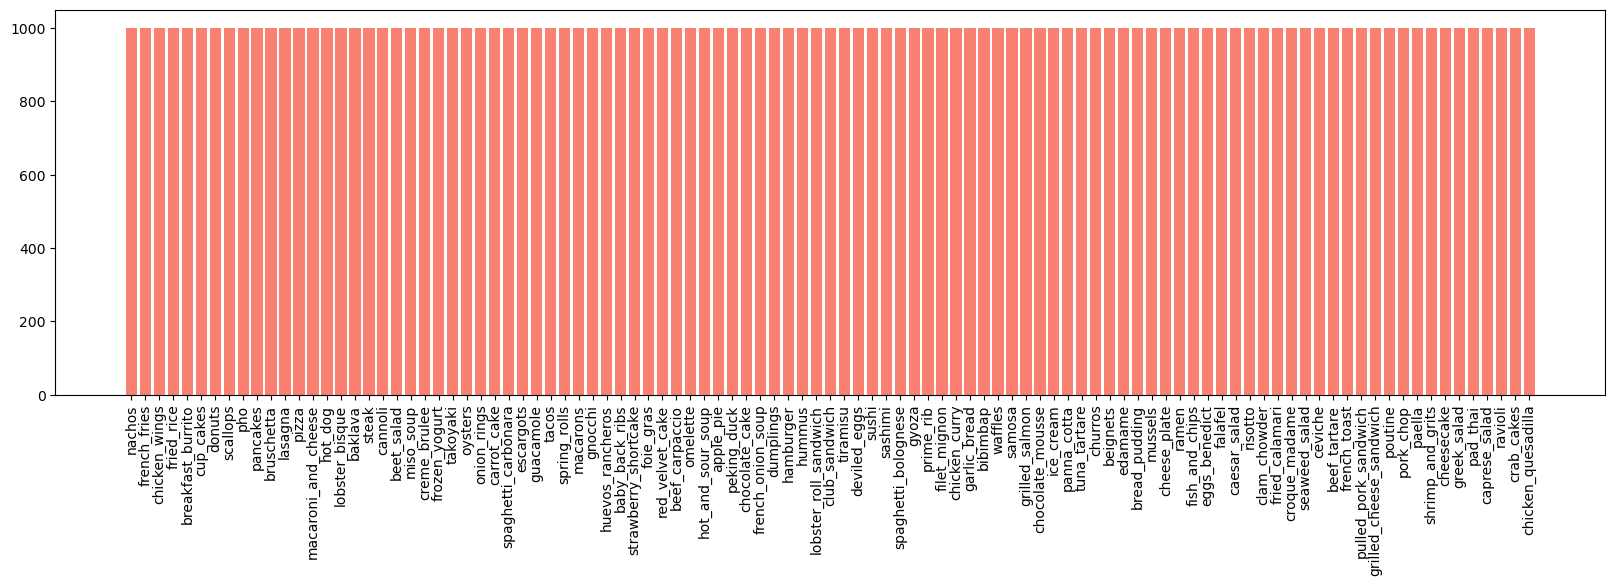

In [8]:
# Plotting class distribution
files = os.listdir(path)
num_classes = len(files)
print ('Number of classes:', num_classes)

# class distribution
distribution = dict()

for f in files:
    distribution[f] = len(os.listdir(path/f))

plt.figure(figsize=(20, 5))
plt.bar(list(distribution.keys()), distribution.values(), color='salmon')
plt.xticks(rotation=90)
plt.show() 

In [9]:
import matplotlib.pyplot as plt
import random
from PIL import Image


def show_img(rows, cols, figsize=None):
    fig, ax = plt.subplots(rows, cols, figsize=figsize)
    for i in range(rows):
        for j in range(cols):
            random_folder = random.choice(files)
            random_file = random.choice(os.listdir(path/random_folder))
            im = Image.open(path/random_folder/random_file)
            ax[i, j].imshow(im)
            ax[i, j].set_xlabel(str(random_folder) + " " + str(im.size))
            ax[i, j].set_yticklabels([])
            ax[i, j].set_xticklabels([])
            ax[i, j].grid(False)

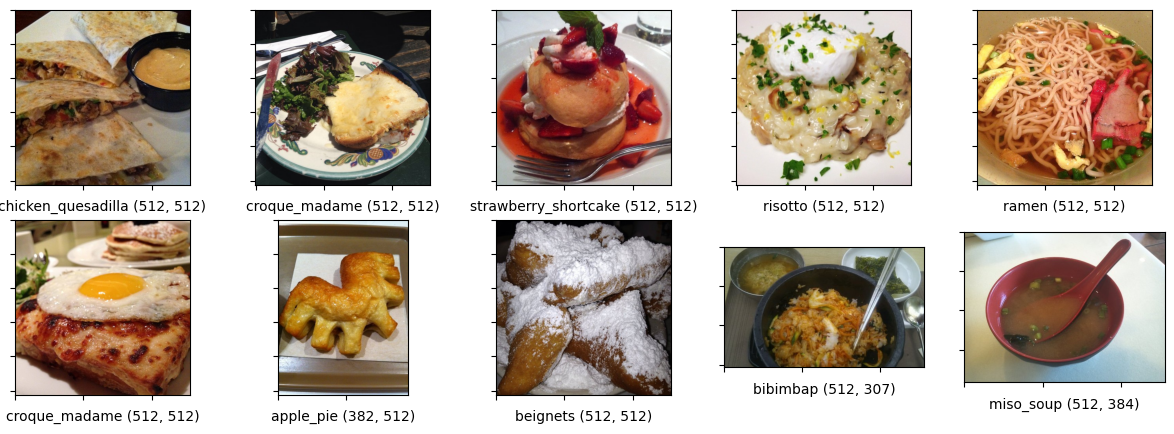

In [10]:
seed_everything(777)
show_img(2, 5, (15, 5))

## 1.2 Split the data from train into current_train and current_val (val_size = 10%)

In [10]:
from torchvision import transforms
from torch import nn


seed_everything(777)

In [11]:
# resize, make Tensor, Normalize
transform_food = transforms.Compose([transforms.Resize((224,224)), transforms.ToTensor(), transforms.Normalize((0.485, 0.456, 0.406), (0.229, 0.224, 0.225))])
train_food = Food101('food_dir',split='train',download=True, transform = transform_food)
validation_food = Food101('food_dir',split='test',download=True, transform = transform_food)

In [99]:
# splitting
seed_everything(777)


train_size, validation_size = int(len(train_food)*0.9), int(len(train_food)*0.1)
current_train, current_val = torch.utils.data.random_split(train_food, [train_size, validation_size])

In [100]:
# create Dataloader
from torch.utils.data import DataLoader


batch_size = 32

train_dataloader = torch.utils.data.DataLoader(current_train, batch_size=batch_size, shuffle = True)
val_dataloader = torch.utils.data.DataLoader(current_val, batch_size=batch_size, shuffle = True)
test_dataloader = torch.utils.data.DataLoader(test_food, batch_size=batch_size)

# 2. ResNet50 Fine-tuning

## 2.1 Take pre-trained ResNet from torchvision

In [77]:
from torchvision.models import resnet50, ResNet50_Weights
import time


seed_everything(777)

In [78]:
# !pip install validators

In [79]:
resnet50 = torch.hub.load('NVIDIA/DeepLearningExamples:torchhub', 'nvidia_resnet50', pretrained=True)
utils = torch.hub.load('NVIDIA/DeepLearningExamples:torchhub', 'nvidia_convnets_processing_utils')
resnet50.fc = torch.nn.Linear(resnet50.fc.in_features, 101)
torch.nn.init.xavier_uniform_(resnet50.fc.weight)
resnet50.eval().to(device)

Using cache found in /root/.cache/torch/hub/NVIDIA_DeepLearningExamples_torchhub
Using cache found in /root/.cache/torch/hub/NVIDIA_DeepLearningExamples_torchhub


ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layers): Sequential(
    (0): Sequential(
      (0): Bottleneck(
        (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (downsample): Sequential(
          (0): Conv2d

## 2.2 Fine-tune pre-trained ResNet50 on current_train created in 1.2.

In [80]:
def train(
        net,
        train_dataloader,
        valid_dataloader,
        criterion,
        optimizer,
        epochs=10,
        device='cpu'):
    start = time.time()
    print(f'Start fine-tuning process on {device} device ({epochs} epochs)\n{"-"*55}')

    # stores for visualization
    train_accuracy_plot, valid_accuracy_plot = [], []

    # loop for each epoch
    seed_everything(777)
    prev_val_acc = 0
    
    for epoch in range(1, epochs + 1):
        print(f"Epoch {epoch}/{epochs}\n{'-'*55}")

        # training process
        net.train()
        train_loss = torch.tensor(0., device=device)
        train_accuracy = torch.tensor(0., device=device)

        for X, y in tqdm(train_dataloader, desc="Train"):
            X = X.to(device)
            y = y.to(device)
            preds = net(X)
            loss = criterion(preds, y)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            with torch.no_grad():
                train_loss += loss * train_dataloader.batch_size
                train_accuracy += (torch.argmax(preds, dim=1) == y).sum()

        # validation process
        net.eval()
        valid_loss = torch.tensor(0., device=device)
        valid_accuracy = torch.tensor(0., device=device)

        with torch.no_grad():
            for X, y in tqdm(valid_dataloader, desc="Validation"):
                X = X.to(device)
                y = y.to(device)
                preds = net(X)
                loss = criterion(preds, y)
                valid_loss += loss * valid_dataloader.batch_size
                valid_accuracy += (torch.argmax(preds, dim=1) == y).sum()

        # results of training and validation
        curr_train_acc = (100 * train_accuracy / len(train_dataloader.dataset)).item()
        curr_val_acc = (100 * valid_accuracy / len(valid_dataloader.dataset)).item()
        curr_train_loss = (train_loss / len(train_dataloader.dataset)).item()
        curr_val_loss = (valid_loss / len(valid_dataloader.dataset)).item()

        # print epoch's results
        print('-'*55)
        print(pd.DataFrame(
            {'Loss': [curr_train_loss, curr_val_loss], 'Accuracy': [curr_train_acc, curr_val_acc]}, 
            index=['Train', 'Validation']).round(2))
        print('-'*55)

        # plotting
        train_accuracy_plot.append(curr_train_acc)
        valid_accuracy_plot.append(curr_val_acc)

        if epoch > 1:
            df = pd.DataFrame(
                {'Train': train_accuracy_plot, 'Validation': valid_accuracy_plot},
                index=range(1, epoch+1))

            ax = sns.lineplot(data=df[['Train', 'Validation']])
            ax.set(xlabel='Epochs', ylabel='Accuracy, %')
            ax.set(xticks=range(1, epoch+1))

        # check for overfitting
        if (curr_val_acc < prev_val_acc+0.1) or (curr_train_acc > curr_val_acc+1):
            print(f"{'-'*55}Training and validation processes are finished")
            print(f"The resulting validation accuracy is {curr_val_acc}%")
            
            torch.save({
                'epoch': epoch,
                'state_dict': net.state_dict(),
                'optimizer': optimizer.state_dict(),
            }, './checkpoint.pth.tar')
            
            break
        prev_val_acc = curr_val_acc
    
    
    end = time.time()
    print(f'{"-"*55}\nTotal training takes {(end - start)/60:.2f} minutes')
    
    return net

In [81]:
from torch import optim

lr = 1e-5
weight_decay = 5e-4
epochs = 5
criterion = torch.nn.CrossEntropyLoss()

params_except_fc = [param for name, param in resnet50.named_parameters() if 'fc' not in str(name)]
optimizer = torch.optim.Adam(
    [
        {'params':params_except_fc}, 
        {'params': resnet50.fc.parameters(), 'lr': lr*10}
    ], 
    lr=lr, weight_decay=weight_decay
)

Start fine-tuning process on cuda device (5 epochs)
-------------------------------------------------------
Epoch 1/5
-------------------------------------------------------


Train:   0%|          | 0/2131 [00:00<?, ?it/s]

Validation:   0%|          | 0/237 [00:00<?, ?it/s]

-------------------------------------------------------
            Loss  Accuracy
Train       2.58     40.86
Validation  1.54     60.88
-------------------------------------------------------
Epoch 2/5
-------------------------------------------------------


Train:   0%|          | 0/2131 [00:00<?, ?it/s]

Validation:   0%|          | 0/237 [00:00<?, ?it/s]

-------------------------------------------------------
            Loss  Accuracy
Train       1.29     66.82
Validation  1.22     68.03
-------------------------------------------------------
Epoch 3/5
-------------------------------------------------------


Train:   0%|          | 0/2131 [00:00<?, ?it/s]

Validation:   0%|          | 0/237 [00:00<?, ?it/s]

-------------------------------------------------------
            Loss  Accuracy
Train       0.93     75.72
Validation  1.10     71.14
-------------------------------------------------------
-------------------------------------------------------Training and validation processes are finished
The resulting validation accuracy is 71.14191436767578%
-------------------------------------------------------
Total training takes 38.84 minutes


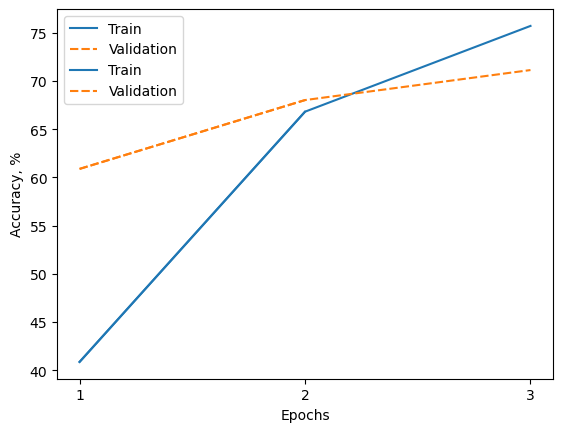

In [82]:
RN50 = train(resnet50, train_dataloader, val_dataloader, criterion, optimizer, epochs, device)

## 2.3 Evaluate your fine-tuned model (use accuracy metric and data from test part for the evaluation), analyze the results and make conclusions.

In [101]:
test_loss = torch.tensor(0., device=device)
test_accuracy = torch.tensor(0., device=device)

with torch.no_grad():
    start = time.time()
    print(f'Start evaluating process on {device} device\n{"-"*55}')
    for X, y in tqdm(test_dataloader, desc="Evaluation"):
        X = X.to(device)
        y = y.to(device)
        preds = RN50(X)
        loss = criterion(preds, y)
        test_loss += loss * test_dataloader.batch_size
        test_accuracy += (torch.argmax(preds, dim=1) == y).sum()
    end = time.time()
    print(f'{"-"*55}\nTotal evaluation time: {(end - start)/60:.2f} minutes')
        
print(f'Test loss: {test_loss/len(test_dataloader.dataset):.2f}')
print(f'Test accuracy: {100*test_accuracy/len(test_dataloader.dataset):.2f}')

Start evaluating process on cuda device
-------------------------------------------------------


Evaluation:   0%|          | 0/790 [00:00<?, ?it/s]

-------------------------------------------------------
Total evaluation time: 3.02 minutes
Test loss: 1.05
Test accuracy: 71.64


The lower the loss, the better a model (unless the model has over-fitted to the training data). The loss is calculated on training and validation and its interperation is how well the model is doing for these two sets. Unlike accuracy, loss is not a percentage. It is a summation of the errors made for each example in training or validation sets. Loss value implies how well or poorly a certain model behaves after each iteration of optimization. Ideally, one would expect the reduction of loss after each, or several, iteration(s). And we have seen this decreasing, and the training process was stopped when the accuracy on validation got lower than on train.

Accuracy measures how well our model predicts by comparing the model predictions with the true values in terms of percentage. We have a model that is able to predict correctly in approximately 72% of cases in the given dataset.


# 3. Vit Fine-tuning

## 3.2 Take Vit model from HuggingFace library and initialize it with the weights pre-trained on ImageNet.

In [ ]:
transform_food = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
    ])

train_food = Food101('food_dir',split='train',download=True,transform=transform_food)
test_food = Food101('food_dir',split='test',download=True,transform=transform_food)

seed_everything(777)

train_size, validation_size = int(len(train_food)*0.9), int(len(train_food)*0.1)
current_train, current_val = torch.utils.data.random_split(train_food, [train_size, validation_size])

In [88]:
from transformers import ViTFeatureExtractor, ViTForImageClassification, TrainingArguments, Trainer


model_name = 'google/vit-base-patch16-224-in21k'
feature_extractor = ViTFeatureExtractor.from_pretrained(model_name)

Vit = ViTForImageClassification.from_pretrained (
    "google/vit-base-patch16-224",
    num_labels=len(train_food.classes),
    id2label= train_food.classes,
    label2id=test_food._labels,
    ignore_mismatched_sizes = True)
torch.nn.init.xavier_uniform_(Vit.classifier.weight)

Some weights of ViTForImageClassification were not initialized from the model checkpoint at google/vit-base-patch16-224 and are newly initialized because the shapes did not match:
- classifier.weight: found shape torch.Size([1000, 768]) in the checkpoint and torch.Size([101, 768]) in the model instantiated
- classifier.bias: found shape torch.Size([1000]) in the checkpoint and torch.Size([101]) in the model instantiated
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Parameter containing:
tensor([[ 0.0526,  0.0781,  0.0224,  ...,  0.0339,  0.0184, -0.0674],
        [ 0.0796,  0.0500, -0.0298,  ...,  0.0584,  0.0489,  0.0658],
        [ 0.0085, -0.0189, -0.0458,  ...,  0.0581,  0.0440,  0.0024],
        ...,
        [ 0.0184, -0.0460, -0.0287,  ...,  0.0344,  0.0360,  0.0755],
        [ 0.0740, -0.0149, -0.0252,  ..., -0.0562, -0.0132, -0.0208],
        [-0.0227,  0.0774,  0.0700,  ..., -0.0506,  0.0567,  0.0267]],
       requires_grad=True)

In [90]:
training_args = TrainingArguments(
    'vit-base-patch16-224-in21k',
    eval_steps=100,
    evaluation_strategy="epoch",
    fp16=True,
    gradient_accumulation_steps=4,
    learning_rate=2e-4,
    load_best_model_at_end=True,
    logging_steps=10,
    num_train_epochs=5,
    metric_for_best_model="accuracy",
    per_device_train_batch_size=32,
    per_device_eval_batch_size=32,
    push_to_hub=False,
    remove_unused_columns=False,
    report_to='none',
    save_steps=100,
    save_strategy="epoch",
    save_total_limit=2,
    warmup_ratio=0.1,
)

In [92]:
from datasets import load_metric


metric_accuracy = load_metric("accuracy")


def compute_metrics(p):
    predictions = np.argmax(p.predictions, axis=1)
    references = p.label_ids
    metric_accuracy.add_batch(predictions=predictions, references=references)
    score =  metric_accuracy.compute()
    return score


def collate_fn(examples):
    pixel_values = torch.stack([example[0] for example in examples])
    labels = torch.tensor([example[1] for example in examples])
    return {"pixel_values": pixel_values, "labels": labels}

## 3.3 Similarly to point 2, fine-tune this model on on current_train created in 1.2. Do not forget about validation on current_val created in 1.2 in process of training.

In [93]:
trainer = Trainer(
    Vit,
    training_args,
    train_dataset=current_train,
    eval_dataset=current_val,
    tokenizer=feature_extractor,
    compute_metrics=compute_metrics,
    data_collator=collate_fn,
)

In [94]:
train_results = trainer.train()
trainer.save_model()
trainer.log_metrics("train", train_results.metrics)
trainer.save_metrics("train", train_results.metrics)
trainer.save_state()

Epoch,Training Loss,Validation Loss,Accuracy
0,0.732500,0.708793,0.815182
2,0.377600,0.667453,0.828647
2,0.119600,0.642771,0.838680
4,0.025400,0.674944,0.842508
4,0.002900,0.675537,0.851221


***** train metrics *****
  epoch                    =          4.99
  total_flos               = 24580100374GF
  train_loss               =        0.4306
  train_runtime            =    2:18:19.97
  train_samples_per_second =        41.069
  train_steps_per_second   =          0.16


## 3.4 Evaluate your fine-tuned model (use accuracy metric and data from test part for the evaluation), analyze the results and make conclusions.

In [95]:
metrics = trainer.evaluate()
trainer.log_metrics("validation", metrics)
trainer.save_metrics("validation", metrics)

***** validation metrics *****
  epoch                   =       4.99
  eval_accuracy           =     0.8512
  eval_loss               =     0.6755
  eval_runtime            = 0:01:25.36
  eval_samples_per_second =      88.74
  eval_steps_per_second   =      1.394


In [97]:
metrics = trainer.evaluate(test_food)
trainer.log_metrics("test", metrics)
trainer.save_metrics("test", metrics)

***** test metrics *****
  epoch                   =       4.99
  eval_accuracy           =     0.8963
  eval_loss               =     0.4453
  eval_runtime            = 0:05:31.11
  eval_samples_per_second =     76.256
  eval_steps_per_second   =      1.193


As we can see from statistics tables, for Vit model 3 epochs is enouch to terminate the training process (because the validation's loss starts get poorer: on the third epoch it was ~0.64, but on the fourth it became ~0.67). This model is able to predict correctly in approximately 84% of cases in the given dataset.

# 4. Summary & results analysis

## 4.1 Compare the results of the tested models. First, compare them between each other (ResNet vs ViT), that with other models on leaderboard.

| Model | Accuracy | Loss |
| --- | --- | --- |
| ResNet50 | 72% | 1.05 |
| Vit | 90% | 0.45 |
| Bamboo (ViTB/16) (leaderboard) | 93% | - |

The Vit model certainly performs better than the ResNet50 in terms of accuracy as well as losses: on Vit there is 2 times less of loss. But according to the leaderbord there is better performance in Bamboo model where accuracy is 93%.

## 4.2 Propose, how you may improve the model score (write at least three ideas).

We can improve ResNet50 with:
- adding another dense layer before the Dense layer
- experimenting with different learning rates
- playing with additional augmentations to the dataset

References:<br>
- A. Steiner and others "How to train your ViT? Data, Augmentation, and Regularization in Vision Transformers", 2022 https://arxiv.org/pdf/2106.10270.pdf

### Thank you!